In [1]:
import sys
from pathlib import Path
from dotenv import load_dotenv
env_path = Path(r"F:\code_repo\abTEM\.env")
load_dotenv(env_path)
import os
print(os.getenv("Materials_Project_API_KEY"))  # 应该输出你的 key

# 将项目根目录加入 Python 路径（从 notebooks 目录向上找到 multem_cgs 根目录）
project_root = Path.cwd()
for _ in range(10):
    if (project_root / "abTEM").exists() or (project_root / "materials").exists():
        break
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from abtem.multislice import CVDMSMultislice, FourierMultislice

# Materials Project 数据接口（从 abTEM 导入）
from abtem.materials import (
    fetch_structure,
    get_structure_by_id,
    mp_structure_to_atoms,
    search_materials,
    is_available,
)

0T7KeTs9suzB9lWHh04qKqNGkCtMT9sU


In [2]:
# 检查依赖项
from abtem.materials.mp_client import MP_API_AVAILABLE, PYMATGEN_AVAILABLE, ASE_AVAILABLE
print(f"mp-api: {MP_API_AVAILABLE}")
print(f"pymatgen: {PYMATGEN_AVAILABLE}")
print(f"ase: {ASE_AVAILABLE}")


mp-api: True
pymatgen: True
ase: True


(examples:cbed_quickstart)=
# CBED quickstart

This notebook demonstrates a basic CBED simulation of silicon in the $(111)$ zone axis.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [3]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "cupy",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
);

## Atomic model
We create the atomic model. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models.

We fetch the crystal structure from the [Materials Project](https://materialsproject.org) database. Enter a material name to search, browse the available candidates, and pick one by index.

Retrieving SummaryDoc documents:   0%|          | 0/4 [00:00<?, ?it/s]

找到 4 个 'SrTiO3' 相关材料：

  # | MP ID        | 化学式        | 空间群        | 晶系           |    稳定 |   E_hull |    带隙
--------------------------------------------------------------------------------------
  0 | mp-4651      | SrTiO3     | I4/mcm     | Tetragonal   |     ✓ |   0.0000 | 1.849
  1 | mp-551830    | SrTiO3     | I4/mcm     | Tetragonal   |       |   0.0001 | 1.787
  2 | mp-5229      | SrTiO3     | Pm-3m      | Cubic        |       |   0.0005 | 1.772
  3 | mp-776018    | SrTiO3     | P6_3/mmc   | Hexagonal    |       |   0.0391 | 1.736


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

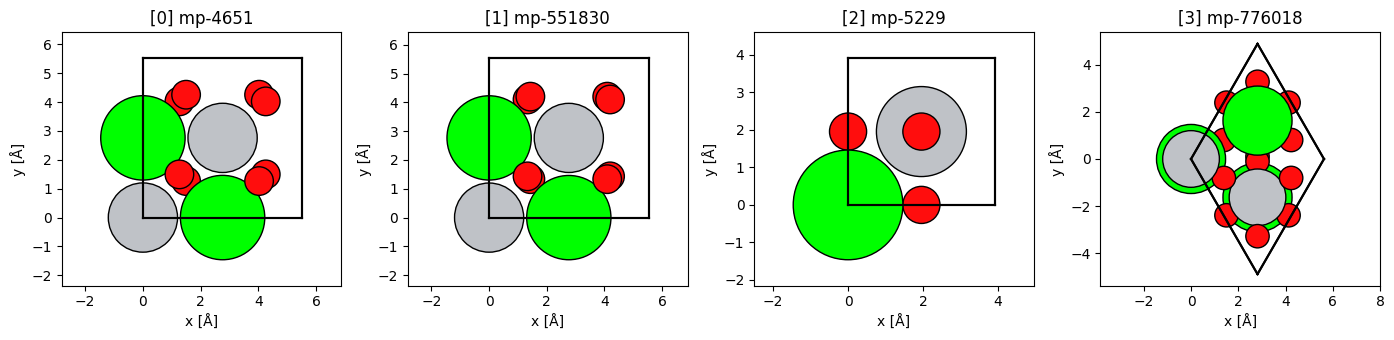

In [4]:
# ============================================================
# 从 Materials Project 搜索晶体结构
# ============================================================
# 在这里设置要模拟的材料名称
MATERIAL = "SrTiO3"

if not MATERIAL:
    raise ValueError("请设置 MATERIAL 变量")

if not is_available():
    raise RuntimeError(
        "Materials Project 不可用。请确保已配置 MP_API_KEY 环境变量，"
        "或安装 mp-api / pymatgen 依赖。"
    )

# 搜索材料
result = search_materials(MATERIAL, max_results=8)

if not result["success"]:
    raise RuntimeError(f"搜索失败: {result.get('error')}")
elif result["count"] == 0:
    raise ValueError(f"在 Materials Project 中未找到 '{MATERIAL}'")
else:
    candidates = result["results"]
    print(f"找到 {len(candidates)} 个 '{MATERIAL}' 相关材料：\n")

    # 打印候选列表
    header = f"{'#':>3} | {'MP ID':<12} | {'化学式':<10} | {'空间群':<10} | {'晶系':<12} | {'稳定':>5} | {'E_hull':>8} | {'带隙':>5}"
    print(header)
    print("-" * len(header))
    for i, m in enumerate(candidates):
        stable = "✓" if m["is_stable"] else " "
        spgr = m.get("space_group", "N/A") or "N/A"
        csys = m.get("crystal_system", "N/A") or "N/A"
        ehull = f"{m['energy_above_hull']:.4f}" if m["energy_above_hull"] is not None else "N/A"
        bgap = f"{m['band_gap']:.3f}" if m["band_gap"] is not None else "N/A"
        print(f"{i:>3} | {m['material_id']:<12} | {m['formula']:<10} | {spgr:<10} | {csys:<12} | {stable:>5} | {ehull:>8} | {bgap:>5}")

    # 可视化所有候选结构的晶胞
    n = len(candidates)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.atleast_1d(axes).ravel()
    for i, m in enumerate(candidates):
        struct = get_structure_by_id(m["material_id"], conventional=True)
        if struct["success"]:
            atoms_i = mp_structure_to_atoms(struct["structure"])
            abtem.show_atoms(atoms_i, ax=axes[i], title=f"[{i}] {m['material_id']}")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()




使用: [2] mp-5229 (SrTiO3)


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

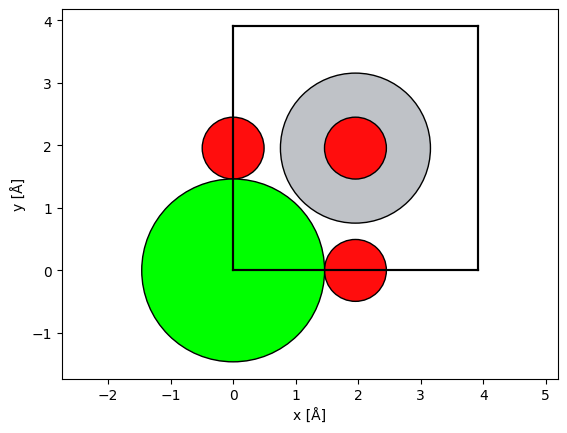

In [5]:
# ============================================================
# 选择使用哪个结构 — 改这个索引即可切换
SELECTED_INDEX = 2
# ============================================================

selected = candidates[SELECTED_INDEX]
print(f"\n使用: [{SELECTED_INDEX}] {selected['material_id']} ({selected['formula']})")
struct = get_structure_by_id(selected["material_id"], conventional=True)
structure = mp_structure_to_atoms(struct["structure"])

abtem.show_atoms(structure, plane="xy");

We can choose the $(111)$ zone axis to be a propagation direction using the `surface` function. 

Finally we repeat the structure in $x$ and $y$, this will improve the reciprocal space resolution. We also repeat the structure in $z$, thus simulating a thicker sample.

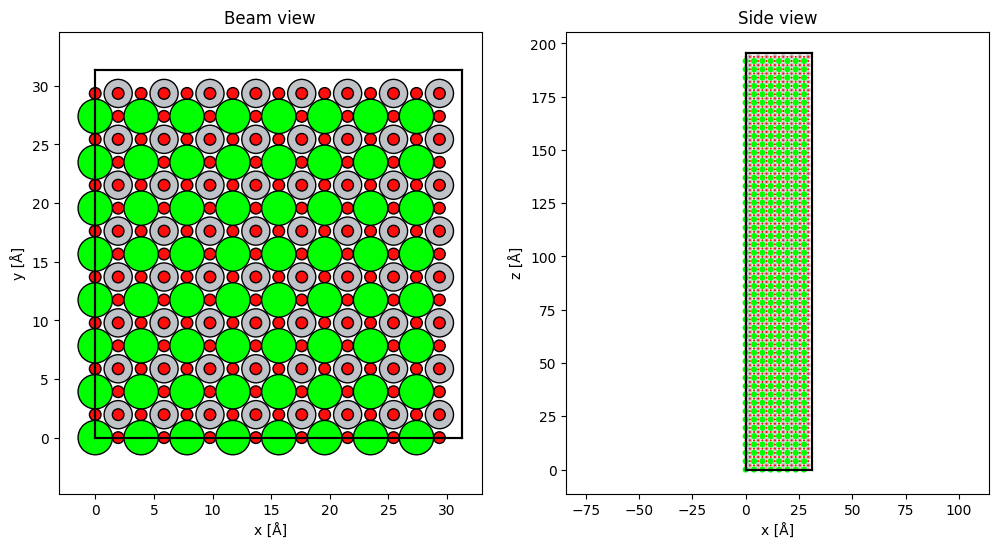

In [6]:
#structure = abtem.orthogonalize_cell(structure)
atoms = structure * (8, 8, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
abtem.show_atoms(atoms, ax=ax1, title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", linewidth=0.0);

## Potential

We create an ensemble of potentials using the frozen phonon. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [7]:
frozen_phonons = abtem.FrozenPhonons(atoms, 32, {"Sr":0.164356, "Ti": 0.116584, "O": 0.148198})

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [8]:
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.05,
    projection="finite",
    slice_thickness=0.4,
    exit_planes=60,
)

total_z = atoms.cell[2, 2]

# 采样信息
gx, gy = potential.gpts
sx, sy = potential.sampling
lx, ly = potential.extent
sz = potential.slice_thickness[0]
dkx = 1.0 / lx
dky = 1.0 / ly
dkz = 1.0 / total_z

n_slices = int(total_z / sz)
print(f"Thickness: {total_z:.2f} A, slices: {n_slices}")

print(f"Grid: {gx} x {gy}")
print(f"Real-space sampling: dx={sx:.4f} A, dy={sy:.4f} A, dz={sz:.4f} A")
print(f"Extent: Lx={lx:.2f} A, Ly={ly:.2f} A, Lz={total_z:.2f} A")
print(f"Reciprocal-space sampling: dkx={dkx:.6f} 1/A, dky={dky:.6f} 1/A, dkz={dkz:.6f} 1/A")
print(f"Nyquist freq: kx_max={gx*dkx/2:.4f} 1/A, ky_max={gy*dky/2:.4f} 1/A")

Thickness: 195.64 A, slices: 490
Grid: 627 x 627
Real-space sampling: dx=0.0499 A, dy=0.0499 A, dz=0.3993 A
Extent: Lx=31.30 A, Ly=31.30 A, Lz=195.64 A
Reciprocal-space sampling: dkx=0.031947 1/A, dky=0.031947 1/A, dkz=0.005112 1/A
Nyquist freq: kx_max=10.0155 1/A, ky_max=10.0155 1/A


## Wave function

We create a probe wave function at an energy of 100 keV with a convergence semiangle of $9.4 \ \mathrm{mrad}$. See our [walkthrough on wave functions](walkthrough:wave_functions). 

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence) if you want to include this in your simulation.

In [9]:
wave = abtem.Probe(energy=30e3, semiangle_cutoff=35)
wave.grid.match(potential)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

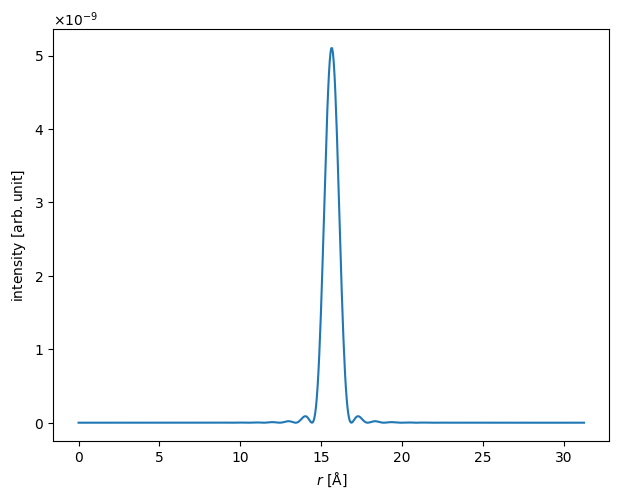

In [10]:
wave.profiles().show();

## Multislice with CVDMS

We run the multislice algorithm using the **CVDMS (Coupled-Wave Dynamical Multislice)** algorithm, which accounts for backscattering coupling between slices for higher accuracy compared to the conventional Fourier multislice method.

We configure the algorithm with explicit parameter control: order-1 expansion with backscattering corrections enabled.

In [11]:
cvdms_algorithm = CVDMSMultislice(
    order=1,
    convergence_threshold=1e-6,
    max_terms=50,
    use_fused_kernel=True,
    backscattering=True,
    check_interval=2,  # 2
)

measurements = wave.multislice(
    potential,
    algorithm=cvdms_algorithm,#FourierMultislice(order=1),
).diffraction_patterns(max_angle="cutoff")

We take the mean across the frozen phonons axis, and compute the result.

In [ ]:
measurement = measurements.mean(0)

measurement.compute();

tasks:   0%|          | 0/130 [00:00<?, ?it/s]

## Visualize results

We show the thickness series as an exploded plot.

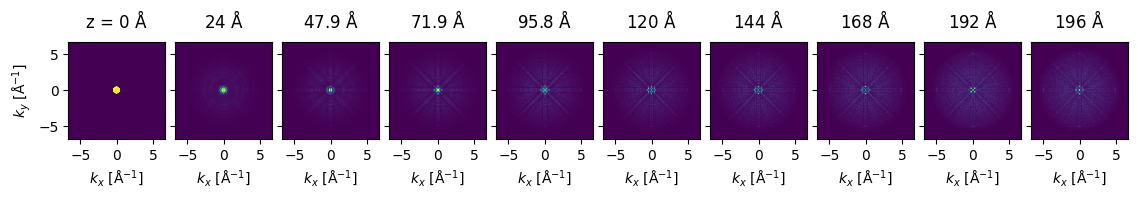

In [ ]:
visualization = measurement.show(
    explode=True,
    figsize=(12, 5),
)

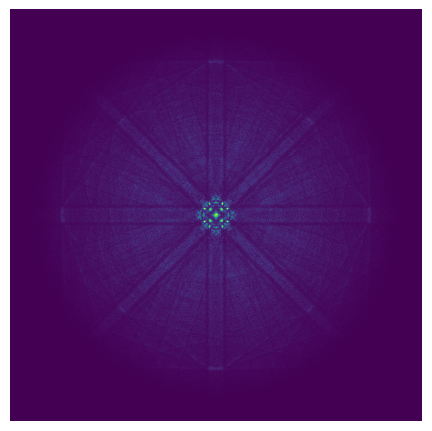

In [ ]:
# this cell produces a thumbnail for the online documentation

visualization = measurement[-1].show()
visualization.axis_off()
plt.savefig("cbed_quickstart.png", bbox_inches="tight", pad_inches=0)

In [ ]:
arr = measurement.array
if hasattr(arr, 'get'):
    arr = arr.get()

img = np.asarray(arr)
while img.ndim > 2:
    img = img[-1]

try:
    ang = getattr(measurement, 'angular_sampling', None)
    if ang is not None:
        ang = (float(ang[0]), float(ang[1]))
except Exception:
    ang = None

try:
    mx = getattr(measurement, 'max_angles', None)
    if mx is not None:
        mx = (float(mx[0]), float(mx[1]))
except Exception:
    mx = None

try:
    pot_gpts = getattr(potential, 'gpts', None)
except Exception:
    pot_gpts = None

print('potential shape (gpts):', pot_gpts)
print('CBED pattern shape (raw):', img.shape)
print('angular_sampling (mrad/px):', ang)
print('max_angles (mrad):', mx)

potential shape (gpts): (627, 627)
CBED pattern shape (raw): (419, 419)
angular_sampling (mrad/px): (2.2296237918408934, 2.2296237918408934)
max_angles (mrad): (465.9913724947467, 465.9913724947467)


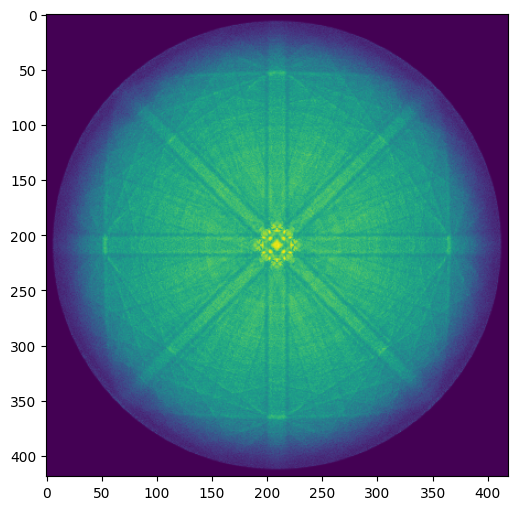

In [ ]:
fix, ax = plt.subplots(1, 1, figsize=(6, 6))
# Match the notebook convention: log(transpose(last_exit_plane)).
with np.errstate(divide='ignore', invalid='ignore'):
    C = 1.5e3
    ax.imshow(np.log(1+C*img/np.max(img)), cmap="viridis")

plt.savefig("cvdms_cbed.png", dpi=300)
plt.show()